## 1. Instalación de Dependencias

In [16]:
!pip install kagglehub scikit-learn pandas numpy matplotlib seaborn

## 2. Importar Librerías

In [17]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Descargar y Cargar el Dataset de IMDb

In [18]:
# Descargar dataset desde Kaggle Hub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(f"Dataset descargado en: {path}")

Dataset descargado en: C:\Users\Dell\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [19]:
# Cargar en DataFrame
df = pd.read_csv(f"{path}/IMDB Dataset.csv")
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 4. Exploración de Datos (EDA)

In [20]:
print("=== Información general del dataset ===")
print(df.info())
print(f"Distribución de clases:")
print(df['sentiment'].value_counts())
print(f"Porcentaje por clase:")
print(df['sentiment'].value_counts(normalize=True).map(lambda x: f"{x:.1%}"))

=== Información general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
Distribución de clases:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Porcentaje por clase:
sentiment
positive    50.0%
negative    50.0%
Name: proportion, dtype: object


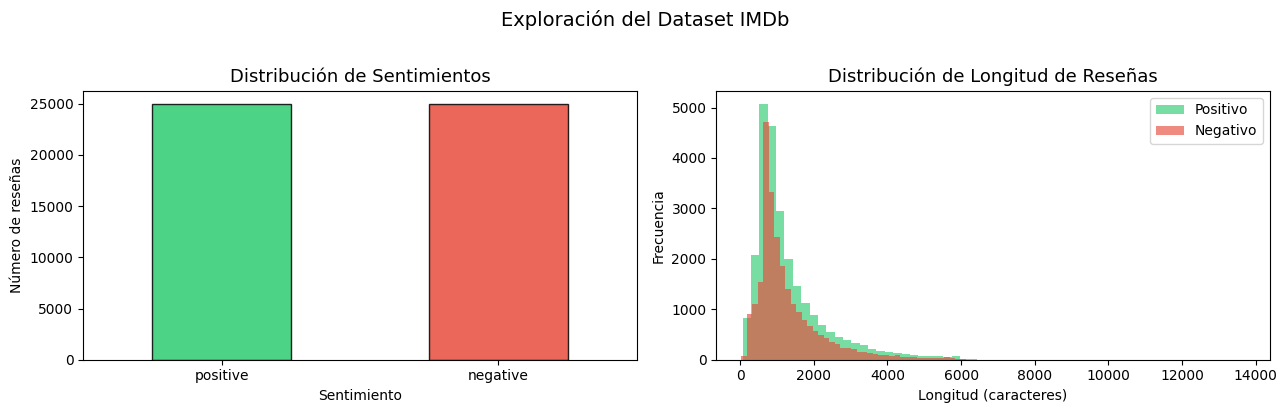

In [21]:
# Distribución de sentimientos y longitud de reseñas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de clases
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribución de Sentimientos', fontsize=13)
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Número de reseñas')
axes[0].tick_params(axis='x', rotation=0)

# Longitud de reseñas por clase
df['longitud'] = df['review'].apply(len)
axes[1].hist(df[df['sentiment'] == 'positive']['longitud'], bins=60,
             alpha=0.65, color='#2ecc71', label='Positivo')
axes[1].hist(df[df['sentiment'] == 'negative']['longitud'], bins=60,
             alpha=0.65, color='#e74c3c', label='Negativo')
axes[1].set_title('Distribución de Longitud de Reseñas', fontsize=13)
axes[1].set_xlabel('Longitud (caracteres)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Exploración del Dataset IMDb', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Preprocesamiento y Vectorización TF-IDF

In [22]:
# Codificar etiquetas: negative=0, positive=1
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])
print(f"Clases: {label_encoder.classes_} -> {[0, 1]}")

# Muestra para agilizar el entrenamiento
# Comentar las dos líneas siguientes para usar todo el dataset (50 000 registros)
sample_size = 5000
df_sample = df.sample(n=sample_size, random_state=42)
print(f"Muestra seleccionada: {len(df_sample)} registros")
print(df_sample['sentiment'].value_counts())

# División entrenamiento / prueba (80/20, estratificada)
X = df_sample['review']
y = df_sample['sentiment_encoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Conjunto de entrenamiento : {len(X_train)} registros")
print(f"Conjunto de prueba        : {len(X_test)} registros")

# Vectorización TF-IDF con unigramas y bigramas
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f"Dimensión del vector TF-IDF (entrenamiento): {X_train_tfidf.shape}")

Clases: ['negative' 'positive'] -> [0, 1]
Muestra seleccionada: 5000 registros
sentiment
positive    2519
negative    2481
Name: count, dtype: int64
Conjunto de entrenamiento : 4000 registros
Conjunto de prueba        : 1000 registros
Dimensión del vector TF-IDF (entrenamiento): (4000, 5000)


---
## MÉTODO 1: Support Vector Machine (SVM)

**Descripción:** Las Máquinas de Vectores de Soporte (SVM) buscan el hiperplano de máximo margen que separa las clases en el espacio de características. Con kernel lineal son especialmente eficaces para clasificación de texto en espacios TF-IDF de alta dimensionalidad.

**Ventajas:**
- Excelente rendimiento en datos de alta dimensionalidad y escasos.
- Robusto ante el sobreajuste en comparación con métodos basados en distancia.
- El parámetro `C` permite controlar el balance entre margen y errores de clasificación.

**Desventajas:**
- Computacionalmente costoso con datasets muy grandes (complejidad O(n²) a O(n³)).
- No ofrece probabilidades de clase de forma directa (requiere calibración adicional).
---

In [23]:
print("=" * 60)
print("  ENTRENANDO MODELO SVM (kernel lineal, C=1.0)")
print("=" * 60)

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print("Modelo SVM entrenado correctamente.")

accuracy_svm  = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm    = recall_score(y_test, y_pred_svm)
f1_svm        = f1_score(y_test, y_pred_svm)

print(f"Exactitud  (Accuracy) : {accuracy_svm:.4f}")
print(f"Precisión  (Precision): {precision_svm:.4f}")
print(f"Cobertura  (Recall)   : {recall_svm:.4f}")
print(f"F1-Score              : {f1_svm:.4f}")
print(f"Reporte de clasificación completo:")
print(classification_report(y_test, y_pred_svm, target_names=['Negativo', 'Positivo']))

  ENTRENANDO MODELO SVM (kernel lineal, C=1.0)
Modelo SVM entrenado correctamente.
Exactitud  (Accuracy) : 0.8590
Precisión  (Precision): 0.8566
Cobertura  (Recall)   : 0.8651
F1-Score              : 0.8608
Reporte de clasificación completo:
              precision    recall  f1-score   support

    Negativo       0.86      0.85      0.86       496
    Positivo       0.86      0.87      0.86       504

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



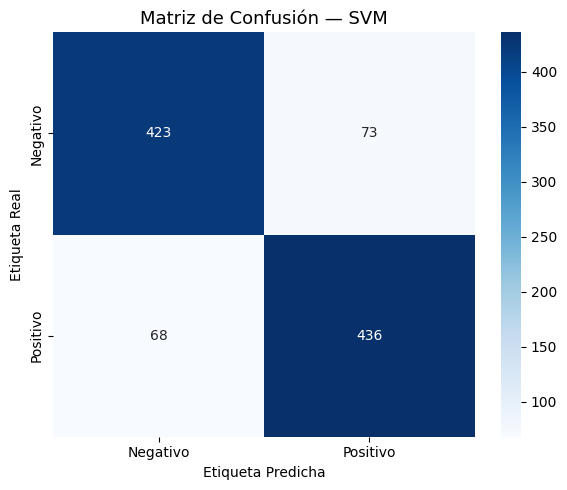

In [24]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión — SVM', fontsize=13)
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

---
## MÉTODO 2: K-Nearest Neighbors (KNN)

**Descripción:** KNN clasifica una instancia basándose en las *k* instancias más cercanas en el espacio de representación. Es un algoritmo *lazy* (no construye un modelo explícito): almacena todo el conjunto de entrenamiento y calcula distancias en la fase de predicción. Con la métrica coseno es adecuado para representaciones TF-IDF.

**Ventajas:**
- Extremadamente simple de implementar y sin fase de entrenamiento explícita.
- La métrica coseno maneja bien la dispersión de los vectores TF-IDF.

**Desventajas:**
- Lento en la predicción cuando el conjunto de entrenamiento es grande.
- Sensible a características irrelevantes y altamente dependiente del valor de *k*.
---

In [25]:
print("=" * 60)
print("  ENTRENANDO MODELO KNN (k=5, métrica coseno)")
print("=" * 60)

knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_model.fit(X_train_tfidf, y_train)
y_pred_knn = knn_model.predict(X_test_tfidf)
print("Modelo KNN entrenado correctamente.")

accuracy_knn  = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn    = recall_score(y_test, y_pred_knn)
f1_knn        = f1_score(y_test, y_pred_knn)

print(f"Exactitud  (Accuracy) : {accuracy_knn:.4f}")
print(f"Precisión  (Precision): {precision_knn:.4f}")
print(f"Cobertura  (Recall)   : {recall_knn:.4f}")
print(f"F1-Score              : {f1_knn:.4f}")
print(f"Reporte de clasificación completo:")
print(classification_report(y_test, y_pred_knn, target_names=['Negativo', 'Positivo']))

  ENTRENANDO MODELO KNN (k=5, métrica coseno)
Modelo KNN entrenado correctamente.
Exactitud  (Accuracy) : 0.7000
Precisión  (Precision): 0.7257
Cobertura  (Recall)   : 0.6508
F1-Score              : 0.6862
Reporte de clasificación completo:
              precision    recall  f1-score   support

    Negativo       0.68      0.75      0.71       496
    Positivo       0.73      0.65      0.69       504

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000



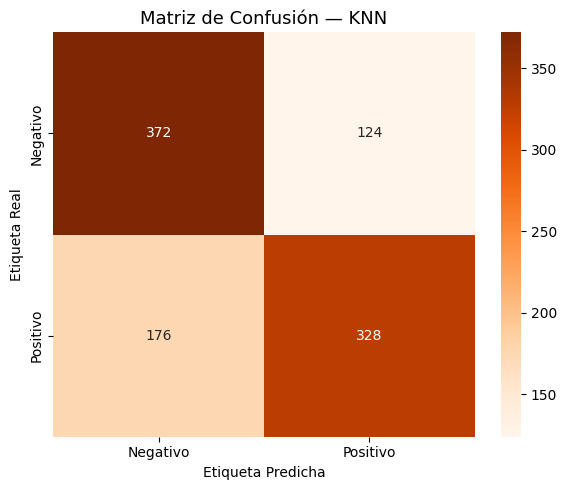

In [26]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión — KNN', fontsize=13)
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

---
## MÉTODO 3: Naive Bayes (Multinomial)

**Descripción:** Naive Bayes aplica el teorema de Bayes asumiendo independencia condicional entre características. La variante Multinomial es apropiada para datos de conteo o frecuencias como TF-IDF. A pesar de su fuerte suposición de independencia, NB tiene un rendimiento sorprendentemente competitivo en clasificación de texto.

**Ventajas:**
- Entrenamiento extremadamente rápido y bajo consumo de memoria.
- Funciona bien incluso con pocos datos de entrenamiento.
- Probabilístico por naturaleza: devuelve directamente probabilidades de clase.

**Desventajas:**
- La suposición de independencia entre palabras es poco realista (ignora orden y contexto).
- Sensible a características correlacionadas (doble conteo del peso de evidencia).
---

In [27]:
print("=" * 60)
print("  ENTRENANDO MODELO NAIVE BAYES (Multinomial)")
print("=" * 60)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Modelo Naive Bayes entrenado correctamente.")

accuracy_nb  = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb    = recall_score(y_test, y_pred_nb)
f1_nb        = f1_score(y_test, y_pred_nb)

print(f"Exactitud  (Accuracy) : {accuracy_nb:.4f}")
print(f"Precisión  (Precision): {precision_nb:.4f}")
print(f"Cobertura  (Recall)   : {recall_nb:.4f}")
print(f"F1-Score              : {f1_nb:.4f}")
print(f"Reporte de clasificación completo:")
print(classification_report(y_test, y_pred_nb, target_names=['Negativo', 'Positivo']))

  ENTRENANDO MODELO NAIVE BAYES (Multinomial)
Modelo Naive Bayes entrenado correctamente.
Exactitud  (Accuracy) : 0.8330
Precisión  (Precision): 0.8350
Cobertura  (Recall)   : 0.8333
F1-Score              : 0.8342
Reporte de clasificación completo:
              precision    recall  f1-score   support

    Negativo       0.83      0.83      0.83       496
    Positivo       0.83      0.83      0.83       504

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



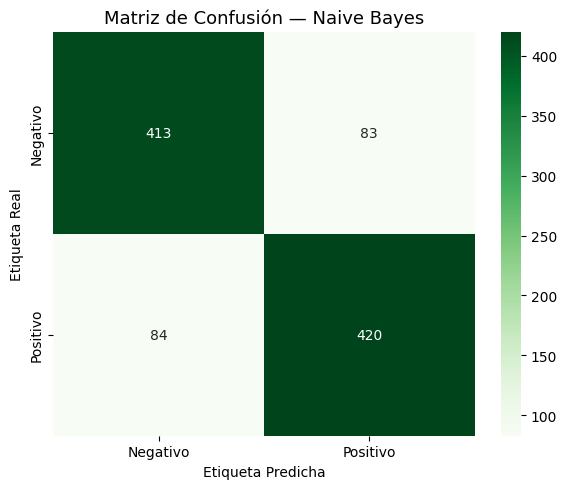

In [28]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión — Naive Bayes', fontsize=13)
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

## 6. Comparación de los Tres Modelos

Resumen de métricas por modelo:
     Modelo Accuracy Precision Recall F1-Score
        SVM   0.8590    0.8566 0.8651   0.8608
        KNN   0.7000    0.7257 0.6508   0.6862
Naive Bayes   0.8330    0.8350 0.8333   0.8342


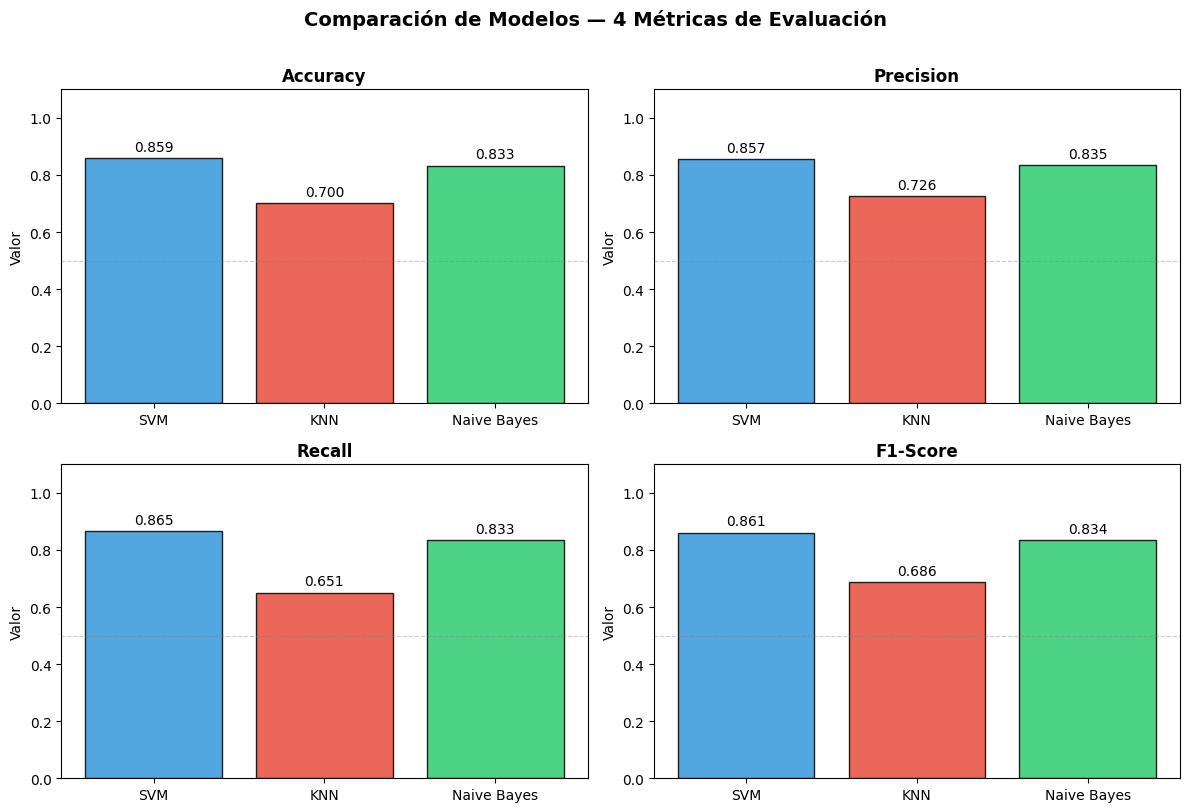

In [29]:
# ── Tabla resumen de métricas ───────────────────────────────
resultados = pd.DataFrame({
    'Modelo'    : ['SVM', 'KNN', 'Naive Bayes'],
    'Accuracy'  : [accuracy_svm,  accuracy_knn,  accuracy_nb],
    'Precision' : [precision_svm, precision_knn, precision_nb],
    'Recall'    : [recall_svm,    recall_knn,    recall_nb],
    'F1-Score'  : [f1_svm,        f1_knn,        f1_nb],
})

resultados_fmt = resultados.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    resultados_fmt[col] = resultados_fmt[col].map(lambda x: f"{x:.4f}")

print("Resumen de métricas por modelo:")
print(resultados_fmt.to_string(index=False))

# ── Gráfico comparativo 2×2 ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#3498db', '#e74c3c', '#2ecc71']
modelos = ['SVM', 'KNN', 'Naive Bayes']

for ax, metric in zip(axes.flatten(), metrics):
    valores = resultados[metric].values
    bars = ax.bar(modelos, valores, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Valor')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparación de Modelos — 4 Métricas de Evaluación',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Predictor Personalizado

Se usa el modelo de mejor rendimiento (SVM) para clasificar nuevas reseñas escritas por el usuario.

In [30]:
def predecir_sentimiento(texto, modelo=svm_model, vec=vectorizer, encoder=label_encoder):
    '''Predice el sentimiento de una reseña usando el modelo SVM entrenado.'''
    texto_vec = vec.transform([texto])
    pred      = modelo.predict(texto_vec)[0]
    score     = modelo.decision_function(texto_vec)[0]
    clase     = encoder.inverse_transform([pred])[0]
    polaridad = "POSITIVO (+)" if clase == 'positive' else "NEGATIVO (-)"
    print(f"Texto     : {texto[:90]}{'...' if len(texto) > 90 else ''}")
    print(f"Prediccion: {polaridad}  |  Score decision: {score:+.4f}")
    print("-" * 70)
    return clase

# ── Ejemplos de prueba ───────────────────────────────────────
ejemplos = [
    "This movie is absolutely fantastic! The acting is superb and the story is deeply moving.",
    "What a waste of time. Terrible plot, bad acting, and a completely boring ending.",
    "One of the most brilliant films I have ever seen. A masterpiece of storytelling.",
    "Complete garbage. I cannot believe anyone funded such a poorly directed mess.",
    "The cinematography was breathtaking, but unfortunately the script had major flaws.",
]

print("=" * 70)
print("  PREDICCIONES CON EJEMPLOS PERSONALIZADOS (SVM)")
print("=" * 70)
print()
for ej in ejemplos:
    predecir_sentimiento(ej)

  PREDICCIONES CON EJEMPLOS PERSONALIZADOS (SVM)

Texto     : This movie is absolutely fantastic! The acting is superb and the story is deeply moving.
Prediccion: POSITIVO (+)  |  Score decision: +1.3960
----------------------------------------------------------------------
Texto     : What a waste of time. Terrible plot, bad acting, and a completely boring ending.
Prediccion: NEGATIVO (-)  |  Score decision: -4.9036
----------------------------------------------------------------------
Texto     : One of the most brilliant films I have ever seen. A masterpiece of storytelling.
Prediccion: POSITIVO (+)  |  Score decision: +1.8452
----------------------------------------------------------------------
Texto     : Complete garbage. I cannot believe anyone funded such a poorly directed mess.
Prediccion: NEGATIVO (-)  |  Score decision: -2.0475
----------------------------------------------------------------------
Texto     : The cinematography was breathtaking, but unfortunately the script